<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/TransactionCostModeling_and_OptimalExectution(Almgren_Chriss_Model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# STATIC DATA

In [ ]:
# Set seeds for reproducibility
np.random.seed(42)

# --- CONFIGURATION ---
initial_price = 100.0
volatility_daily = 0.02  # 2% daily volatility
n_days = 100
adv = 1_000_000  # Average Daily Volume (shares)

# 1. GENERATE SYNTHETIC PRICE DATA (Geometric Brownian Motion)
# We simulate a "theoretical" mid-price path without any of our trading influence yet.
dt = 1  # 1 day time step
returns = np.random.normal(0, volatility_daily, n_days)
price_path = initial_price * np.exp(np.cumsum(returns))

# Create a DataFrame
df = pd.DataFrame({'Date': pd.date_range(start='2023-01-01', periods=n_days),
                   'MidPrice': price_path})
df['DailyVolume'] = np.random.normal(adv, adv*0.1, n_days) # Add some noise to volume

df.head()

,Date,MidPrice,DailyVolume
0,2023-01-01,100.998379,858462.925795
1,2023-01-02,100.719476,957935.467723
2,2023-01-03,102.032660,965728.548347
3,2023-01-04,105.188455,919772.273078
4,2023-01-05,104.697002,983871.428833


In [ ]:
class TransactionCostModel:
    def __init__(self, commission_bps=5, spread_bps=2, impact_model='sqrt', impact_coeff=0.1):
        """
        commission_bps: Brokerage fee in basis points (1 bp = 0.0001)
        spread_bps: Bid-Ask spread in basis points
        impact_model: 'linear' or 'sqrt' (Square Root Law)
        impact_coeff: Tuning parameter for the impact model (Y in the formula)
        """
        self.commission_rate = commission_bps / 10000.0
        self.half_spread = (spread_bps / 10000.0) / 2.0
        self.impact_model = impact_model
        self.impact_coeff = impact_coeff

    def calculate_explicit_cost(self, price, quantity):
        """Returns the dollar cost of commissions."""
        notional = price * abs(quantity)
        return notional * self.commission_rate

    def calculate_spread_cost(self, price, quantity):
        """Returns the dollar cost of crossing the spread."""
        # You lose half the spread on every trade (buy at Ask, sell at Bid)
        return (price * self.half_spread) * abs(quantity)

    def calculate_market_impact(self, price, quantity, daily_volatility, daily_volume):
        """
        Estimates the price dislocation ($/share) caused by the trade size.
        """
        participation_rate = abs(quantity) / daily_volume

        # Avoid division by zero
        if daily_volume == 0: return 0.0

        if self.impact_model == 'linear':
            # Linear Model: Impact scales linearly with participation
            impact_fraction = self.impact_coeff * daily_volatility * participation_rate

        elif self.impact_model == 'sqrt':
            # Square Root Law: Impact scales with sqrt of participation
            # Formula: Impact = Y * sigma * sqrt(Q / V)
            impact_fraction = self.impact_coeff * daily_volatility * np.sqrt(participation_rate)

        else:
            raise ValueError("Unknown impact model")

        # The impact cost per share is the price * impact_fraction
        # Total impact cost in dollars = (price * impact_fraction) * quantity
        # Note: We take 1/2 of the impact usually, assuming linear accumulation during execution,
        # but for simplicity, we assume the full impact hits the average execution price here.
        per_share_impact = price * impact_fraction
        return per_share_impact * abs(quantity)

    def get_total_cost(self, price, quantity, volatility, volume):
        explicit = self.calculate_explicit_cost(price, quantity)
        spread = self.calculate_spread_cost(price, quantity)
        impact = self.calculate_market_impact(price, quantity, volatility, volume)

        return {
            'Explicit': explicit,
            'Spread': spread,
            'Impact': impact,
            'Total': explicit + spread + impact
        }

# Instantiate models
linear_model = TransactionCostModel(impact_model='linear', impact_coeff=1.0)
sqrt_model = TransactionCostModel(impact_model='sqrt', impact_coeff=1.0)

In [ ]:
# --- SIMULATION PARAMETERS ---
trade_size_shares = 100_000  # Large order (10% of 1M ADV)
current_price = 100.0
current_vol = 0.02
current_adv = 1_000_000

# Calculate Costs
costs_linear = linear_model.get_total_cost(current_price, trade_size_shares, current_vol, current_adv)
costs_sqrt = sqrt_model.get_total_cost(current_price, trade_size_shares, current_vol, current_adv)

# --- DISPLAY RESULTS ---
results = pd.DataFrame([costs_linear, costs_sqrt], index=['Linear Model', 'Sqrt Model'])

print(f"Trade Notional: ${current_price * trade_size_shares:,.2f}")
print("\n--- Cost Breakdown ($) ---")
print(results.round(2))

# Calculate Implementation Shortfall in Basis Points (bps)
results['Total_bps'] = (results['Total'] / (current_price * trade_size_shares)) * 10000
print("\n--- Total Cost in Basis Points ---")
print(results['Total_bps'].round(2))

Trade Notional: $10,000,000.00

--- Cost Breakdown ($) ---
              Explicit  Spread    Impact     Total
Linear Model    5000.0  1000.0  20000.00  26000.00
Sqrt Model      5000.0  1000.0  63245.55  69245.55

--- Total Cost in Basis Points ---
Linear Model    26.00
Sqrt Model      69.25
Name: Total_bps, dtype: float64


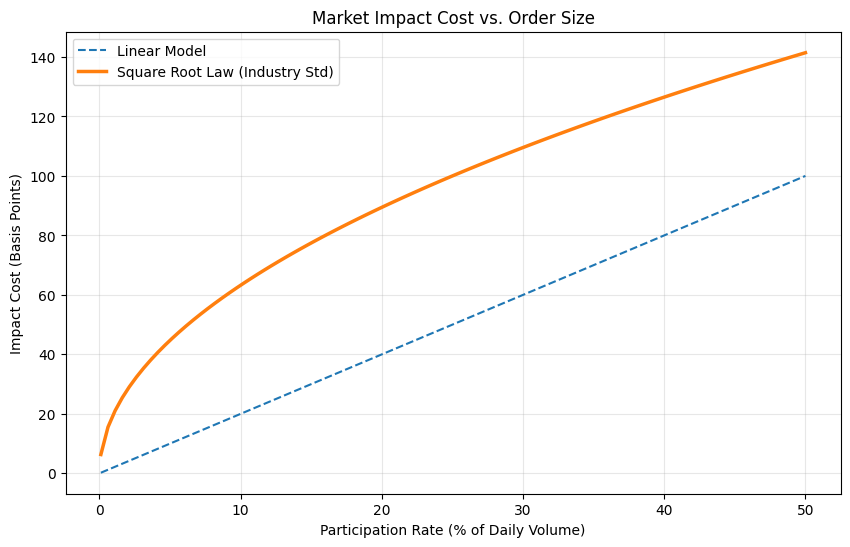

In [ ]:
# Range of trade sizes from 0.1% to 50% of ADV
participation_rates = np.linspace(0.001, 0.5, 100)
quantities = participation_rates * current_adv

impact_linear = []
impact_sqrt = []

for q in quantities:
    c_lin = linear_model.calculate_market_impact(current_price, q, current_vol, current_adv)
    c_sqrt = sqrt_model.calculate_market_impact(current_price, q, current_vol, current_adv)

    # Convert dollar cost back to bps relative to notional for comparison
    notional = current_price * q
    impact_linear.append((c_lin / notional) * 10000)
    impact_sqrt.append((c_sqrt / notional) * 10000)

plt.figure(figsize=(10, 6))
plt.plot(participation_rates * 100, impact_linear, label='Linear Model', linestyle='--')
plt.plot(participation_rates * 100, impact_sqrt, label='Square Root Law (Industry Std)', linewidth=2.5)

plt.title("Market Impact Cost vs. Order Size")
plt.xlabel("Participation Rate (% of Daily Volume)")
plt.ylabel("Impact Cost (Basis Points)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# --- PARAMETERS ---
total_shares = 1_000_000  # Total X
T = 1.0                   # Total time horizon (e.g., 1 day standardized to 1.0)
N = 100                   # Number of trading intervals
dt = T / N                # Time step size
time_grid = np.linspace(0, T, N + 1)

# Market Parameters
sigma = 0.50   # Daily Volatility (in absolute $ terms for simplicity here)
eta = 2.0e-5   # Temporary Impact Coefficient (Cost to trade 1 share quickly)

In [ ]:
# --- ALMGREN-CHRISS TRAJECTORY FUNCTION ---
def get_optimal_trajectory(total_shares, T, N, sigma, eta, risk_aversion_lambda):
    """
    Calculates the Almgren-Chriss optimal execution trajectory.
    Returns: Array of shares remaining at each time step.
    """

    # 1. Calculate Kappa (Urgency Factor)
    # kappa = sqrt( (lambda * sigma^2) / eta )

    if risk_aversion_lambda < 1e-6: # Prevent division by zero / singularity
        kappa = 1e-6
    else:
        kappa = np.sqrt((risk_aversion_lambda * (sigma**2)) / eta)

    # 2. Calculate Shares Remaining x(t) using Hyperbolic Sine
    # Formula: x(t) = X * sinh(kappa * (T - t)) / sinh(kappa * T)

    t_values = np.linspace(0, T, N + 1)
    shares_remaining = total_shares * np.sinh(kappa * (T - t_values)) / np.sinh(kappa * T)

    return shares_remaining

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2226230002.py:16: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(time_grid, trajectory, label=f"{lab} ($\lambda$={lam})", linewidth=2.5)


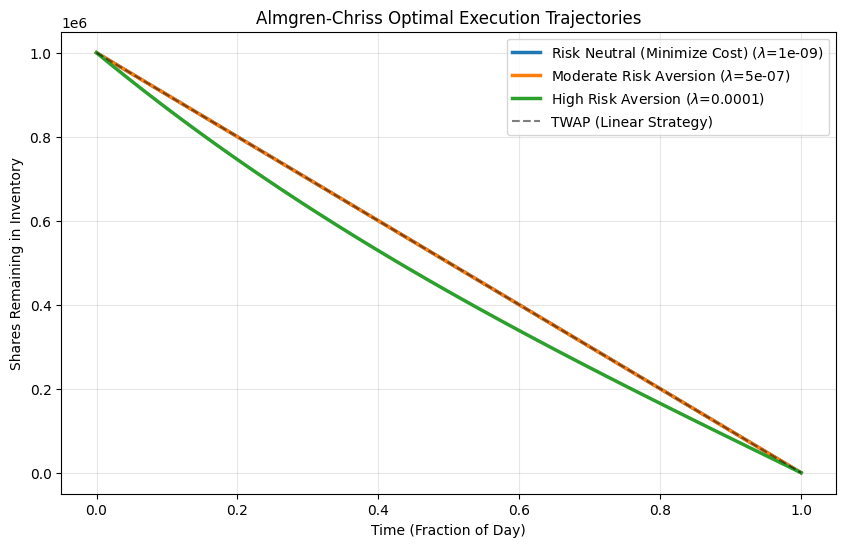

In [ ]:
# --- SIMULATION: COMPARING RISK AVERSIONS ---
# We will compare three traders:
# 1. Risk Neutral (Lambda ~ 0): Don't care about risk, just minimize cost.
# 2. Moderate (Lambda = 1e-6): Balanced view.
# 3. High Risk Aversion (Lambda = 1e-4): Terrified of volatility.

lambdas = [1e-9, 5e-7, 1e-4]
labels = ['Risk Neutral (Minimize Cost)', 'Moderate Risk Aversion', 'High Risk Aversion']

plt.figure(figsize=(10, 6))

for lam, lab in zip(lambdas, labels):
    trajectory = get_optimal_trajectory(total_shares, T, N, sigma, eta, lam)

    # Plotting
    plt.plot(time_grid, trajectory, label=f"{lab} ($\lambda$={lam})", linewidth=2.5)

# Add Reference: TWAP (Time Weighted Average Price) - Linear Execution
plt.plot([0, T], [total_shares, 0], 'k--', alpha=0.5, label='TWAP (Linear Strategy)')

plt.title("Almgren-Chriss Optimal Execution Trajectories")
plt.xlabel("Time (Fraction of Day)")
plt.ylabel("Shares Remaining in Inventory")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()